<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/WHSAT_eda_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

data_set = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv")

In [29]:
# Basic infomation inspection
print(data_set.shape)
print(data_set.columns)
data_set.info()
data_set.head()

(425, 12)
Index(['Unnamed: 0', 'Data', 'Countries', 'Local', 'Industry Sector',
       'Accident Level', 'Potential Accident Level', 'Genre',
       'Employee or Third Party', 'Critical Risk', 'Description',
       'Unnamed: 11'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                425 non-null    int64  
 1   Data                      425 non-null    object 
 2   Countries                 425 non-null    object 
 3   Local                     425 non-null    object 
 4   Industry Sector           425 non-null    object 
 5   Accident Level            425 non-null    object 
 6   Potential Accident Level  425 non-null    object 
 7   Genre                     425 non-null    object 
 8   Employee or Third Party   425 non-null    object 
 9   Critical Risk             425 no

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,0,1/1/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,1,1/2/2016 0:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2,1/6/2016 0:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,3,1/8/2016 0:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,4,1/10/2016 0:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


In [30]:
#renaming so that the columns would have a more meaningful identifier
data_set.rename(columns={"Genre": "Gender", "Data": "Date"}, inplace=True)
data_set['Date']= pd.to_datetime(data_set['Date'])
data_set.drop(labels="Unnamed: 0",axis=1,inplace=True)


In [31]:
data_set.head()

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


In [32]:
#making all the column name lower case and introducing a new seperation "_"
data_set.columns = data_set.columns.str.strip().str.lower().str.replace(" ", "_")
data_set.columns

Index(['date', 'countries', 'local', 'industry_sector', 'accident_level',
       'potential_accident_level', 'gender', 'employee_or_third_party',
       'critical_risk', 'description', 'unnamed:_11'],
      dtype='object')

In [33]:
# Convert date column
data_set['date'] = pd.to_datetime(data_set['date'], errors='coerce')

# Extract temporal features
data_set['hour'] = data_set['date'].dt.hour
data_set['weekday'] = data_set['date'].dt.weekday
data_set['month'] = data_set['date'].dt.month

data_set[['date', 'hour', 'weekday', 'month']].head()

,date,hour,weekday,month
0,2016-01-01,0,4,1
1,2016-01-02,0,5,1
2,2016-01-06,0,2,1
3,2016-01-08,0,4,1
4,2016-01-10,0,6,1


In [34]:
#Accident Level --> I, II, III, IV, V, VI Converting to ordinal 1,2,3,4,5,6
severity_map = {'I': 1, 'II': 2, 'III': 3,'IV': 4, 'V': 5, 'VI': 6}
data_set['severity'] = data_set['accident_level'].map(severity_map)
data_set['potential_severity'] = data_set['potential_accident_level'].map(severity_map)

In [35]:
#Near-Miss Gap
data_set['near_miss_gap'] = data_set['potential_severity'] - data_set['severity']

In [38]:
data_set.head()

,date,countries,local,industry_sector,accident_level,potential_accident_level,gender,employee_or_third_party,critical_risk,description,unnamed:_11,hour,weekday,month,severity,potential_severity,near_miss_gap
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN,0,4,1,1,4,3
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN,0,5,1,1,4,3
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN,0,2,1,1,3,2
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN,0,4,1,1,1,0
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN,0,6,1,4,4,0


In [36]:
#Check missing values
print(data_set.isnull().sum())

#Fill with ""
data_set['description'] = data_set['description'].fillna("")

#removing rows with missing severity
data_set = data_set.dropna(subset=['severity'])

date                          0
countries                     0
local                         0
industry_sector               0
accident_level                0
potential_accident_level      0
gender                        0
employee_or_third_party       0
critical_risk                 0
description                   0
unnamed:_11                 425
hour                          0
weekday                       0
month                         0
severity                      0
potential_severity            0
near_miss_gap                 0
dtype: int64


In [39]:
#categorical_cols = ['industry_sector', 'gender', 'employee_or_third_party', 'critical_risk']
#data_set_encoded = pd.get_dummies(data_set, columns=categorical_cols, drop_first=True)
#data_set_encoded.head()

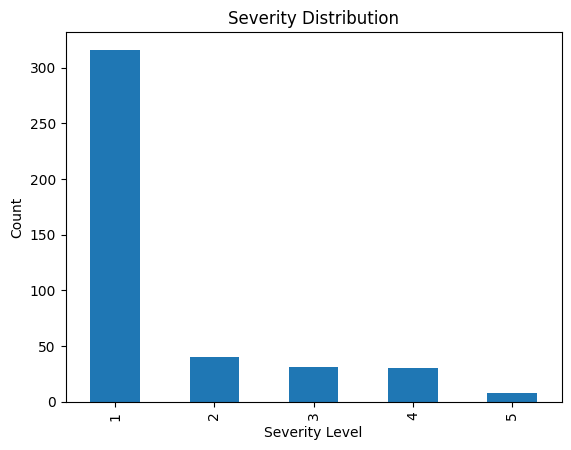

In [41]:
import matplotlib.pyplot as plt

data_set['severity'].value_counts().sort_index().plot(kind='bar')
plt.title("Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

In [42]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(data_set['severity'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=data_set['severity'])

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(1): np.float64(0.2689873417721519), np.int64(2): np.float64(2.125), np.int64(3): np.float64(2.7419354838709675), np.int64(4): np.float64(2.8333333333333335), np.int64(5): np.float64(10.625)}


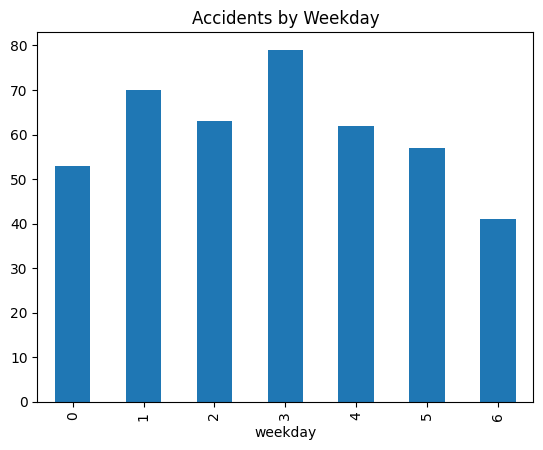

In [44]:
# Accidents by weekday
data_set.groupby('weekday').size().plot(kind='bar')
plt.title("Accidents by Weekday")
plt.show()

In [47]:
from google.colab import files

file_name = "cleaned_safety_data_set_A.csv"
data_set.to_csv(file_name, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>